# MLP Regression Test AstroPT

## Load and crossmatch embeddings and catalog

In [1]:
import numpy as np
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch
from astropy.io import fits
from astropy.table import Table
import umap
import time
from scipy.stats import spearmanr

# Path to astroPT multimodal embeddings
embeddings_dir = Path("/pbs/throng/training/astroinfo2025/data/astroPT_euclid_desi_dataset/astropt/embeddings_output_21000")

print("Loading astroPT multimodal embeddings...")
print(f"Embeddings directory: {embeddings_dir}")

# Check directory contents
if embeddings_dir.exists():
    files = list(embeddings_dir.glob("*.npy")) + list(embeddings_dir.glob("*.npz"))
    print(f"\nFound {len(files)} files:")
    for f in files[:10]:  # Show first 10 files
        print(f"  {f.name}")
    if len(files) > 10:
        print(f"  ... and {len(files) - 10} more")
else:
    print(f"⚠ WARNING: Directory not found: {embeddings_dir}")

# Try to load embeddings (adapt based on actual file structure)
# Common patterns:
# - embeddings.npy, targetids.npy, redshifts.npy
# - embeddings_with_metadata.npz
# - batch_*.npy files

try:
    # Try loading the multimodal training files
    embeddings = np.load(embeddings_dir / "multimodal_train_embeddings.npy")
    target_ids = np.load(embeddings_dir / "multimodal_train_target_ids.npy")
    object_ids = np.load(embeddings_dir / "multimodal_train_object_ids.npy")
    redshifts = np.load(embeddings_dir / "multimodal_train_redshifts.npy")
    has_image = np.load(embeddings_dir / "multimodal_train_has_image.npy")
    has_spectrum = np.load(embeddings_dir / "multimodal_train_has_spectrum.npy")
    
    print(f"\n✓ Embeddings loaded: {embeddings.shape}")
    print(f"✓ Target IDs: {len(target_ids)}")
    print(f"✓ Object IDs: {len(object_ids)}")
    print(f"✓ Redshifts: {len(redshifts)}")
    print(f"  Redshift range: [{redshifts.min():.3f}, {redshifts.max():.3f}]")
    print(f"\n✓ Data availability:")
    print(f"  Has spectrum: {has_spectrum.sum()} ({100*has_spectrum.sum()/len(has_spectrum):.1f}%)")
    print(f"  Has image: {has_image.sum()} ({100*has_image.sum()/len(has_image):.1f}%)")
    print(f"  Has both: {(has_spectrum & has_image).sum()} ({100*(has_spectrum & has_image).sum()/len(has_spectrum):.1f}%)")

except FileNotFoundError as e:
    print(f"\n❌ Could not find embeddings files.")
    print(f"Error: {e}")
    print("\nPlease check the directory structure.")
    raise

Loading astroPT multimodal embeddings...
Embeddings directory: /pbs/throng/training/astroinfo2025/data/astroPT_euclid_desi_dataset/astropt/embeddings_output_21000

Found 8 files:
  multimodal_train_object_ids.npy
  multimodal_train_embeddings.npy
  multimodal_train_redshifts.npy
  multimodal_train_has_image.npy
  embeddings_2d_pca.npy
  multimodal_train_target_ids.npy
  embeddings_10d_pca.npy
  multimodal_train_has_spectrum.npy

✓ Embeddings loaded: (12210, 768)
✓ Target IDs: 12210
✓ Object IDs: 12210
✓ Redshifts: 12210
  Redshift range: [0.009, 1.797]

✓ Data availability:
  Has spectrum: 12210 (100.0%)
  Has image: 12210 (100.0%)
  Has both: 12210 (100.0%)


/pbs/throng/training/astroinfo2025/env/astroclip-conda/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


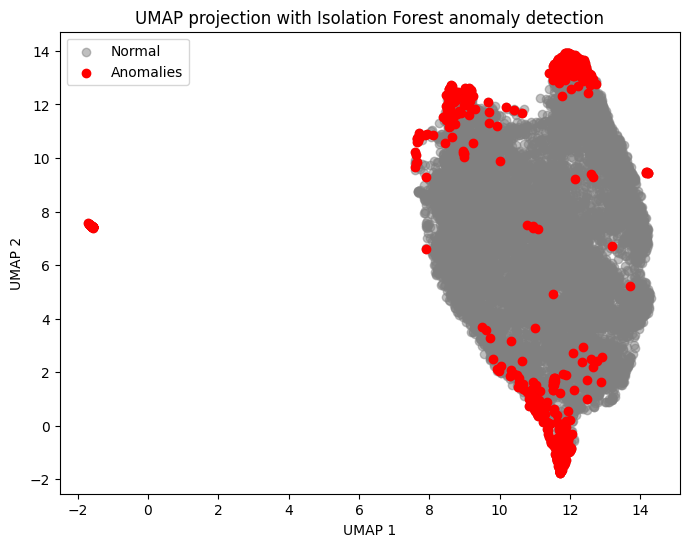

Found 611 anomalies using Isolation Forest with contamination=0.05


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import umap
from sklearn.ensemble import IsolationForest

# Convert embeddings tensor to numpy array if needed
if hasattr(embeddings, 'cpu'):
    emb_np = embeddings.cpu().numpy()
else:
    emb_np = embeddings

# 1. Fit Isolation Forest for anomaly detection
contamination = 0.05  # 5% of data expected to be anomalies, adjust as needed
iso_forest = IsolationForest(contamination=contamination, random_state=42)
iso_forest.fit(emb_np)

# 2. Predict anomalies: -1 is anomaly, 1 is normal
anomaly_labels = iso_forest.predict(emb_np)
anomalies = np.where(anomaly_labels == -1)[0]

# 3. Visualization with UMAP
reducer = umap.UMAP(random_state=42)
embedding_2d = reducer.fit_transform(emb_np)

plt.figure(figsize=(8, 6))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], c='gray', alpha=0.5, label='Normal')
plt.scatter(embedding_2d[anomalies, 0], embedding_2d[anomalies, 1], color='red', label='Anomalies')
plt.legend()
plt.title('UMAP projection with Isolation Forest anomaly detection')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

print(f"Found {len(anomalies)} anomalies using Isolation Forest with contamination={contamination}")


In [3]:

# Path to the combined DESI-Euclid catalog
catalog_path = "/pbs/throng/training/astroinfo2025/data/astroPT_euclid_desi_dataset/desi_euclid_catalog.fits"

print("Loading catalog...")
with fits.open(catalog_path) as hdul:
    catalog = Table(hdul[1].data)

print(f"✓ Catalog loaded: {len(catalog)} entries")
print(f"✓ Available columns ({len(catalog.colnames)}):")
for i, col in enumerate(catalog.colnames[:20]):  # Show first 20 columns
    print(f"  {col}")
if len(catalog.colnames) > 20:
    print(f"  ... and {len(catalog.colnames) - 20} more")



# Find ID column in catalog and determine which embedding IDs to use
id_column = None
embedding_ids_to_match = None

# Try TARGETID first (DESI spectroscopic ID)
if 'TARGETID' in catalog.colnames:
    id_column = 'TARGETID'
    embedding_ids_to_match = target_ids
    print(f"Using catalog ID column: {id_column} (matching with target_ids)")
# Try object_id (Euclid ID)
elif 'object_id' in catalog.colnames:
    id_column = 'object_id'
    embedding_ids_to_match = object_ids
    print(f"Using catalog ID column: {id_column} (matching with object_ids)")
else:
    print("⚠ WARNING: Could not find standard ID column in catalog")
    print("Available columns:", catalog.colnames[:10])

if id_column is not None:
    # Create mapping from object ID to catalog index
    catalog_ids = np.array(catalog[id_column], dtype=np.int64)
    id_to_idx = {int(cid): i for i, cid in enumerate(catalog_ids)}
    
    print(f"\nCatalog ID mapping created: {len(id_to_idx)} unique IDs")
    
    # Convert embedding IDs to int64 for matching
    embedding_ids_int = embedding_ids_to_match.astype(np.int64)
    
    # Match embeddings to catalog
    matched_indices = []
    unmatched_count = 0
    
    for eid in embedding_ids_int:
        if eid in id_to_idx:
            matched_indices.append(id_to_idx[eid])
        else:
            matched_indices.append(-1)
            unmatched_count += 1
    
    matched_indices = np.array(matched_indices)
    match_rate = (len(matched_indices) - unmatched_count) / len(embedding_ids_int) * 100
    
    print(f"\n{'='*60}")
    print(f"MATCHING RESULTS")
    print(f"{'='*60}")
    print(f"✓ Matched: {len(matched_indices) - unmatched_count}/{len(embedding_ids_int)} ({match_rate:.1f}%)")
    
    if unmatched_count > 0:
        print(f"⚠ Unmatched: {unmatched_count} ({100-match_rate:.1f}%)")
    print(f"{'='*60}")



Loading catalog...
✓ Catalog loaded: 15999 entries
✓ Available columns (309):
  object_id
  right_ascension
  declination
  segmentation_area
  flux_h_sersic
  flux_vis_sersic
  ellipticity
  kron_radius
  segmentation_map_id
  VIS_name
  flux_detection_total
  flux_vis_4fwhm_aper
  flux_vis_3fwhm_aper
  flux_vis_2fwhm_aper
  flux_vis_1fwhm_aper
  spurious_flag
  det_quality_flag
  mumax_minus_mag
  smooth_or_featured_smooth
  smooth_or_featured_featured_or_disk
  ... and 289 more
Using catalog ID column: TARGETID (matching with target_ids)

Catalog ID mapping created: 15263 unique IDs

MATCHING RESULTS
✓ Matched: 12210/12210 (100.0%)


In [4]:
# Extract physical properties from catalog
def safe_extract(column_name):
    """Extract column values, filling unmatched entries with NaN"""
    if column_name not in catalog.colnames:
        print(f"⚠ Column '{column_name}' not found in catalog")
        return np.full(len(matched_indices), np.nan, dtype=float)
    
    values = np.full(len(matched_indices), np.nan, dtype=float)
    mask = matched_indices >= 0
    values[mask] = catalog[column_name][matched_indices[mask]]
    return values

def safe_extract_string(column_name):
    """Extract string column values, filling unmatched entries with empty string"""
    if column_name not in catalog.colnames:
        print(f"⚠ Column '{column_name}' not found in catalog")
        return np.full(len(matched_indices), '', dtype=object)
    
    values = np.full(len(matched_indices), '', dtype=object)
    mask = matched_indices >= 0
    values[mask] = [s.strip() if isinstance(s, (str, bytes)) else str(s) for s in catalog[column_name][matched_indices[mask]]]
    return values

print("Extracting physical properties from catalog...\n")

# Key physical properties
if redshifts is None:
    # If redshifts weren't in the embeddings, get them from catalog
    redshifts = safe_extract('Z')
    if np.all(np.isnan(redshifts)):
        redshifts = safe_extract('REDSHIFT')

logm = safe_extract('LOGM')              # Stellar mass
logsfr = safe_extract('LOGSFR')          # Star formation rate
dn4000 = safe_extract('DN4000')          # 4000Å break
gr_color = safe_extract('GR')            # g-r color
spectype = safe_extract_string('SPECTYPE')  # Spectral type

# Derived properties
ssfr = logsfr - logm  # Specific SFR

# Image/morphological properties from Euclid
ellipticity = safe_extract('ellipticity')                        # Ellipticity
kron_radius = safe_extract('kron_radius')                        # Kron radius (size)
concentration = safe_extract('concentration')                     # Concentration index
asymmetry = safe_extract('asymmetry')                            # Asymmetry
smoothness = safe_extract('smoothness')                          # Smoothness/clumpiness
gini = safe_extract('gini')                                      # Gini coefficient
sersic_index = safe_extract('sersic_sersic_vis_index')          # Sérsic index
sersic_radius = safe_extract('sersic_sersic_vis_radius')        # Sérsic radius
axis_ratio = safe_extract('sersic_sersic_vis_axis_ratio')       # Axis ratio

# Additional morphological features
has_spiral_arms = safe_extract('has_spiral_arms_yes')           # Spiral arms presence
disk_edge_on = safe_extract('disk_edge_on_yes')                 # Edge-on disk
det_quality_flag = safe_extract('det_quality_flag')             # Detection quality flag

# Emission line properties
halpha_flux = safe_extract('HALPHA_FLUX')
hbeta_flux = safe_extract('HBETA_FLUX')
# Compute Hα/Hβ ratio (Balmer decrement)
# Valid ratio should be > 2.86 (intrinsic), lower indicates dust attenuation
halpha_hbeta_ratio = np.full(len(halpha_flux), np.nan)
valid_mask = (hbeta_flux > 0) & (halpha_flux > 0)
halpha_hbeta_ratio[valid_mask] = halpha_flux[valid_mask] / hbeta_flux[valid_mask]

# Signal-to-Noise Ratios
snr_b = safe_extract('SNR_B')                                   # SNR in B band
snr_r = safe_extract('SNR_R')                                   # SNR in R band
snr_z = safe_extract('SNR_Z')                                   # SNR in Z band

# Print statistics
print("✓ Spectral/Physical property statistics:")
spectral_properties = {
    'Redshift': redshifts,
    'LOGM (stellar mass)': logm,
    'LOGSFR': logsfr,
    'sSFR (log)': ssfr,
    'DN4000': dn4000,
    'g-r color': gr_color
}

for name, values in spectral_properties.items():
    valid = ~np.isnan(values)
    if valid.sum() > 0:
        print(f"  {name}: {np.nanmean(values):.2f} ± {np.nanstd(values):.2f} (n={valid.sum()})")
    else:
        print(f"  {name}: No valid data")

print("\n✓ Morphological property statistics:")
morphological_properties = {
    'Ellipticity': ellipticity,
    'Kron radius': kron_radius,
    'Concentration': concentration,
    'Asymmetry': asymmetry,
    'Smoothness': smoothness,
    'Gini': gini,
    'Sérsic index': sersic_index,
    'Sérsic radius': sersic_radius,
    'Axis ratio': axis_ratio,
    'Has spiral arms': has_spiral_arms,
    'Disk edge-on': disk_edge_on,
    'Detection quality': det_quality_flag
}

for name, values in morphological_properties.items():
    valid = ~np.isnan(values)
    if valid.sum() > 0:
        print(f"  {name}: {np.nanmean(values):.2f} ± {np.nanstd(values):.2f} (n={valid.sum()})")
    else:
        print(f"  {name}: No valid data")

print("\n✓ Emission line property statistics:")
emission_properties = {
    'Hα/Hβ ratio': halpha_hbeta_ratio,
}

for name, values in emission_properties.items():
    valid = ~np.isnan(values)
    if valid.sum() > 0:
        print(f"  {name}: {np.nanmean(values):.2f} ± {np.nanstd(values):.2f} (n={valid.sum()})")
    else:
        print(f"  {name}: No valid data")

print("\n✓ Signal-to-Noise Ratio statistics:")
snr_properties = {
    'SNR B-band': snr_b,
    'SNR R-band': snr_r,
    'SNR Z-band': snr_z,
}

for name, values in snr_properties.items():
    valid = ~np.isnan(values)
    if valid.sum() > 0:
        print(f"  {name}: {np.nanmean(values):.2f} ± {np.nanstd(values):.2f} (n={valid.sum()})")
    else:
        print(f"  {name}: No valid data")

# Spectral types
unique_spectypes = np.unique(spectype[spectype != ''])
if len(unique_spectypes) > 0:
    print(f"\n✓ Spectral types found: {list(unique_spectypes)}")
    for stype in unique_spectypes:
        count = (spectype == stype).sum()
        print(f"  {stype}: {count:,} ({100*count/len(spectype):.1f}%)")


Extracting physical properties from catalog...

✓ Spectral/Physical property statistics:
  Redshift: 0.37 ± 0.24 (n=12210)
  LOGM (stellar mass): 9.70 ± 2.60 (n=12108)
  LOGSFR: -2.02 ± 4.39 (n=12108)
  sSFR (log): -11.71 ± 5.63 (n=12108)
  DN4000: 1.54 ± 0.48 (n=12210)
  g-r color: 0.50 ± 0.19 (n=12108)

✓ Morphological property statistics:
  Ellipticity: 0.34 ± 0.19 (n=12210)
  Kron radius: 88.36 ± 52.64 (n=12210)
  Concentration: 3.48 ± 0.69 (n=12210)
  Asymmetry: 0.29 ± 0.15 (n=12210)
  Smoothness: 0.22 ± 0.08 (n=12210)
  Gini: 0.66 ± 0.09 (n=12210)
  Sérsic index: 2.30 ± 1.65 (n=12210)
  Sérsic radius: 1.68 ± 2.67 (n=12210)
  Axis ratio: 0.64 ± 0.21 (n=12210)
  Has spiral arms: 43.25 ± 34.90 (n=10812)
  Disk edge-on: 14.29 ± 23.85 (n=10812)
  Detection quality: 23.47 ± 99.70 (n=12210)

✓ Emission line property statistics:
  Hα/Hβ ratio: 818360.88 ± 44014992.72 (n=7798)

✓ Signal-to-Noise Ratio statistics:
  SNR B-band: 0.97 ± 0.94 (n=12210)
  SNR R-band: 3.01 ± 2.00 (n=12210)
  SN

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    embeddings, morphological_properties['Ellipticity'], test_size=0.2, random_state=42)

## MLP Regression

### MLPRegressor

In [9]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score

# X_train, X_test: AstroCLIP embeddings for train and test galaxies
# y_train, y_test: known physical properties

mlp = MLPRegressor(hidden_layer_sizes=(32,), max_iter=500)
mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)
score = r2_score(y_test, y_pred)
print(f"MLP Regression R^2 score: {score:.3f}")

MLP Regression R^2 score: 0.638


### Small MLP

Epoch [50/300] - Train Loss: 0.0953, Val Loss: 0.1432
Epoch [100/300] - Train Loss: 0.0504, Val Loss: 0.1470
Epoch [150/300] - Train Loss: 0.0363, Val Loss: 0.1513
Epoch [200/300] - Train Loss: 0.0298, Val Loss: 0.1491
Epoch [250/300] - Train Loss: 0.0252, Val Loss: 0.1479
Epoch [300/300] - Train Loss: 0.0225, Val Loss: 0.1466


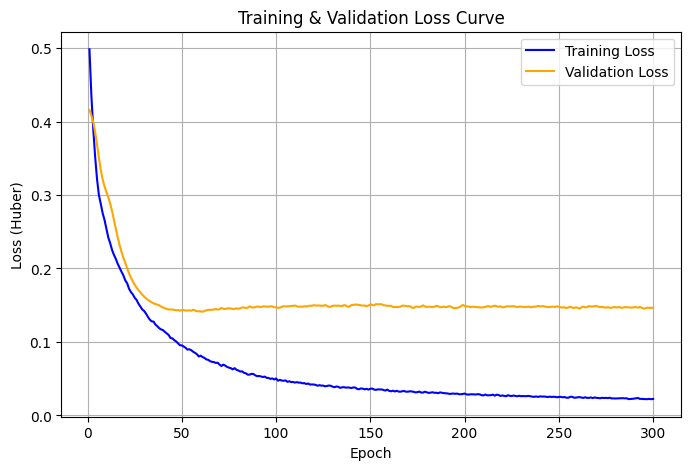

Test R^2: 0.664
Test MAE: 0.084


In [31]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# Prepare data
X_train, X_temp, y_train, y_temp = train_test_split(
    embeddings,
    morphological_properties['Ellipticity'],
    test_size=0.2,
    random_state=42
)

# Validation and test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

# Reshape target y if 1D
def reshape(y):
    return np.asarray(y).reshape(-1, 1) if y.ndim == 1 else y

y_train, y_val, y_test = map(reshape, [y_train, y_val, y_test])

# Standardization
scaler_X = StandardScaler().fit(X_train)
scaler_y = StandardScaler().fit(y_train)

X_train_scaled = scaler_X.transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)
#y_train_scaled = scaler_y.transform(y_train)
#y_val_scaled = scaler_y.transform(y_val)
#y_test_scaled = scaler_y.transform(y_test)

# Convert to tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32)

# MLP model with dropout & batch normalization
class ImprovedMLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(ImprovedMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.network(x)

# Initialize model, optimizer, and loss
input_dim = X_train_t.shape[1]
output_dim = y_train_t.shape[1]
model = ImprovedMLP(input_dim, output_dim)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
criterion = nn.SmoothL1Loss()

# Training
num_epochs = 300
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    train_pred = model(X_train_t)
    train_loss = criterion(train_pred, y_train_t)
    train_loss.backward()
    optimizer.step()

    # Validation
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = criterion(val_pred, y_val_t)

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

# Plot losses
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss', color='blue')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', color='orange')
plt.xlabel("Epoch")
plt.ylabel("Loss (Huber)")
plt.title("Training & Validation Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

# Evaluation
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test_t).numpy()

y_pred_test_orig = scaler_y.inverse_transform(y_pred_test)
y_test_orig = scaler_y.inverse_transform(y_test_scaled)

r2_test = r2_score(y_test_orig, y_pred_test_orig)
mae_test = mean_absolute_error(y_test_orig, y_pred_test_orig)
print(f"Test R^2: {r2_test:.3f}")
print(f"Test MAE: {mae_test:.3f}")


### Visualisation Plots

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming y_true and y_pred arrays in original scale
def plot_true_vs_pred(y_true, y_pred, property_name="Ellipticity"):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, s=10, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel(f"True {property_name}")
    plt.ylabel(f"Predicted {property_name}")
    plt.title("True vs Predicted AstroPT")
    plt.xlim(-0.1,1)
    plt.ylim(-0.1,1)
    plt.grid(True)
    plt.show()

def plot_residuals(y_true, y_pred):
    residuals = y_true - y_pred
    plt.figure(figsize=(6,4))
    plt.scatter(y_true, residuals, s=10, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("True Value")
    plt.ylabel("Residual (True - Predicted)")
    plt.title("Residuals Plot AstroPT")
    plt.grid(True)
    plt.show()

def plot_distributions(y_true, y_pred):
    plt.figure(figsize=(6,4))
    plt.hist(y_true, bins=50, alpha=0.5, label="True", density=True)
    plt.hist(y_pred, bins=50, alpha=0.5, label="Predicted", density=True)
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.title("Distribution Comparison AstroPT")
    plt.legend()
    plt.show()


In [13]:
import numpy as np

def percentage_well_predicted(y_true, y_pred, tolerance=0.1):
    """
    Calculate percentage of predictions with absolute percentage error <= tolerance.

    Parameters:
    - y_true: numpy array of true values
    - y_pred: numpy array of predicted values
    - tolerance: float, e.g., 0.1 means 10% error tolerance

    Returns:
    - percent: float, percentage (0-100) of well-predicted samples
    """
    # Avoid division by zero by adding a small epsilon (or exclude zero targets)
    epsilon = 1e-8
    ape = np.abs(y_true - y_pred) / (np.abs(y_true) + epsilon)
    well_predicted_count = np.sum(ape <= tolerance)
    percent = 100 * well_predicted_count / len(y_true)
    return percent

# Example usage
percent_10pct = percentage_well_predicted(y_test.flatten(), y_pred_test.flatten(), tolerance=0.1)
print(f"Percentage of predictions within 10% error: {percent_10pct:.2f}%")


Percentage of predictions within 10% error: 14.25%


### KNN Test

In [11]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Initialize the KNN regressor
knn = KNeighborsRegressor(n_neighbors=15,weights='distance')

# Fit the KNN model
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred_test = knn.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred_test)
print(f'Mean Squared Error: {mse}')


Mean Squared Error: 0.02657390713433207


In [12]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search over
param_grid = {'n_neighbors': [1, 3, 5, 7, 10, 15, 20], 'weights': ['uniform', 'distance']}

# Initialize the KNN regressor
knn = KNeighborsRegressor()

# Perform grid search with 5-fold cross-validation
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit the grid search
grid_search.fit(X_train, y_train)

# Best parameters found
print("Best parameters:", grid_search.best_params_)

# Evaluate the best model
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error with Grid Search: {mse}')


Best parameters: {'n_neighbors': 15, 'weights': 'distance'}
Mean Squared Error with Grid Search: 0.02657390713433207


In [107]:
from sklearn.ensemble import BaggingRegressor

# Initialize the base KNN regressor
base_knn = KNeighborsRegressor(n_neighbors=15)

# Initialize bagging regressor with base KNN
bagging_knn = BaggingRegressor(base_knn, n_estimators=100, random_state=42)

# Fit the model
bagging_knn.fit(X_train, y_train)

# Evaluate the model
y_pred = bagging_knn.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error with Bagging: {mse}')


/pbs/throng/training/astroinfo2025/env/astroclip-conda/lib/python3.11/site-packages/sklearn/ensemble/_bagging.py:583: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return column_or_1d(y, warn=True)


Mean Squared Error with Bagging: 0.026411261409521103


In [86]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)
y_pred_test = rf.predict(X_test)

print("RMSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred_test))


RMSE: 0.026411260672009825
R²: 0.2757097326054191


### Another MLP

In [93]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Define model
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.layers(x)

model = MLP(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Train
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()

# Evaluate
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test)
mse = criterion(y_pred, y_test).item()
print("MSE:", mse)


/tmp/ipykernel_57909/2360837204.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype=torch.float32)
/tmp/ipykernel_57909/2360837204.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
/tmp/ipykernel_57909/2360837204.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test, dtype=torch.float32)
/tmp/ipykernel_57909/2360837204.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor

MSE: 0.020462751388549805


In [91]:
y_test = y_test.squeeze(1)

# Plots

torch.Size([2442, 1]) torch.Size([2442, 1])


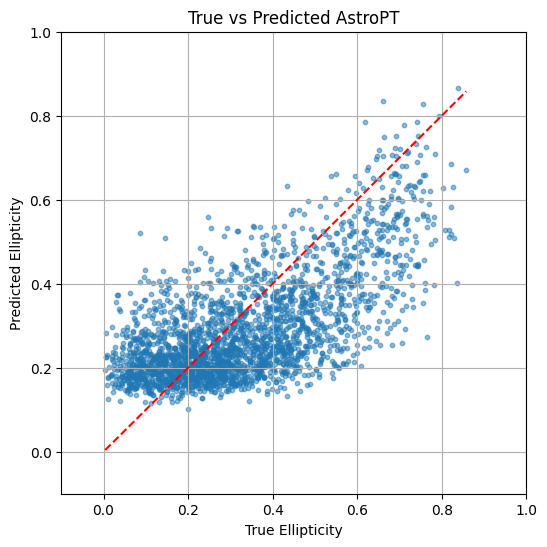

In [106]:
print(y_test.shape, y_pred_test.shape)
plot_true_vs_pred(y_test,y_pred_test)

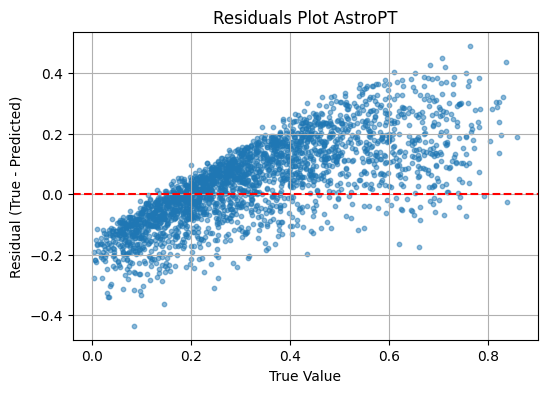

In [95]:
plot_residuals(y_test,y_pred_test)

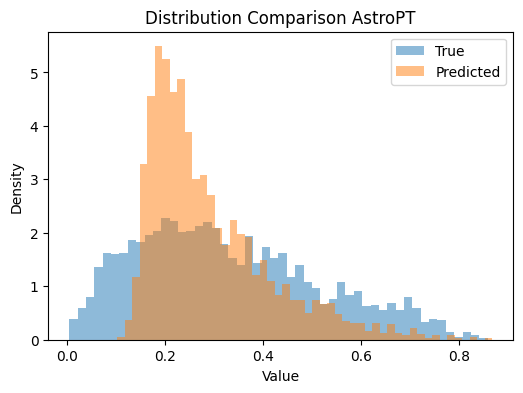

In [96]:
plot_distributions(y_test,y_pred_test)